# Demo 6 — Small optogenetic input (2-D sheet)

Point stimulation on a 2-D sheet. The influence map (opto − baseline response)
shows the center-surround structure of a Mexican-hat network compared with a
random network and an E/I network.

In [1]:
# --- make the package importable ---------------------------------------------
# The package files live flat in this repository folder (itself named
# "cortical_rate_model"), so we add the PARENT directory to the path.
import sys, pathlib
_cwd = pathlib.Path.cwd()
_parent = _cwd.parent if _cwd.name == "cortical_rate_model" else _cwd
sys.path.insert(0, str(_parent))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import cortical_rate_model as crm
from cortical_rate_model import Layout, RateNetwork, EIRateNetwork, make_connectivity, inputs, plotting
print("cortical_rate_model", crm.__version__)

cortical_rate_model 0.1.0


In [2]:
def build_net(kind, layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Single-population network with its recurrent gain set by spectral radius."""
    W = make_connectivity(kind, layout, **params)
    W = crm.scale_spectral_radius(W, spectral_radius)
    return RateNetwork(W, layout=layout, nonlinearity=nonlinearity)

def build_ei(layout, spectral_radius=0.97, nonlinearity="rectification", **params):
    """Two-population E/I network with its recurrent gain set by spectral radius."""
    W, meta = make_connectivity("ei_homogeneous", layout, normalise="spectral",
                                spectral_radius=spectral_radius, **params)
    return EIRateNetwork(W, meta=meta, layout=layout, nonlinearity=nonlinearity)

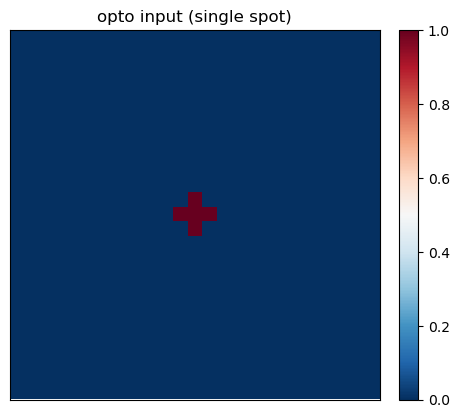

In [3]:
sheet = Layout((25, 25), periodic=True)
center = (12, 12)
baseline = inputs.uniform_input(sheet, 1.0)
opto = inputs.local_stimulation(sheet, center=center, radius=1.0, intensity=1.0,
                                baseline=0.0)
plotting.plot_pattern(opto, sheet, symmetric=False, title="opto input (single spot)")
plt.show()

## Influence maps for different connectivity profiles

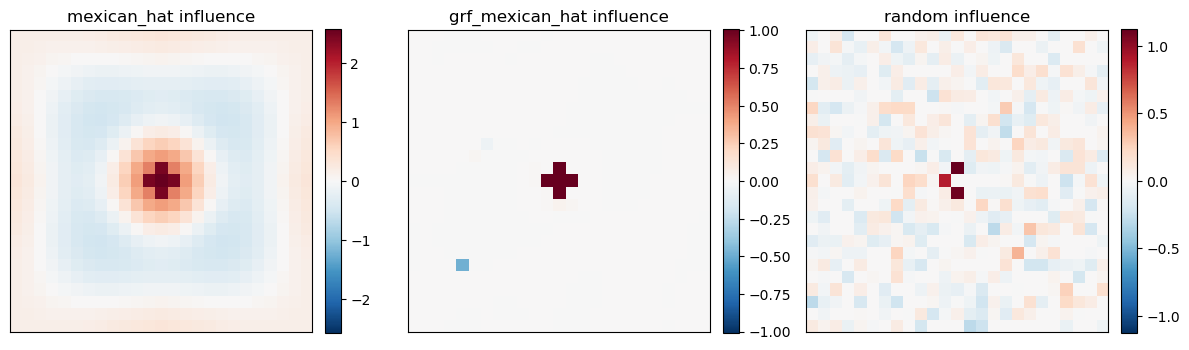

In [4]:
profiles = {
    "mexican_hat":     dict(sigma=1.8, inh_factor=2.5),
    "grf_mexican_hat": dict(sigma=1.8, inh_factor=2.0, grf_strength=0.5),
    "random":          dict(g=1.0),
}
fig, axes = plt.subplots(1, len(profiles), figsize=(4 * len(profiles), 3.6))
for ax, (kind, params) in zip(axes, profiles.items()):
    net = build_net(kind, sheet, spectral_radius=0.95, **params)
    r_base = net.steady_state(baseline, n_steps=400).numpy()
    r_opto = net.steady_state(baseline + opto, n_steps=400).numpy()
    plotting.plot_pattern(r_opto - r_base, sheet, ax=ax, title=f"{kind} influence")
plt.tight_layout(); plt.show()

## E/I network

Excitatory influence map of a point stimulation of the excitatory population.

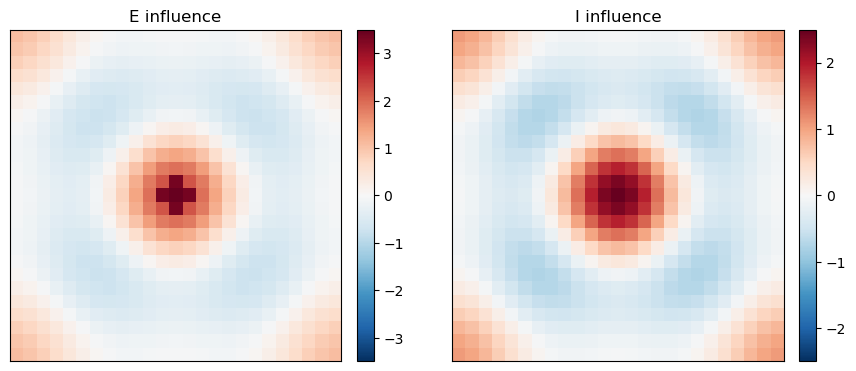

In [5]:
ei = build_ei(sheet, sigma_ee=2.0, sigma_ei=5.0, sigma_ie=2.0, sigma_ii=5.0)
base_ei = inputs.to_ei_input(exc_input=inputs.uniform_input(sheet, 1.0),
                             num_units=sheet.num_units)
opto_ei = inputs.to_ei_input(exc_input=opto, num_units=sheet.num_units)
r_base = ei.steady_state(base_ei, n_steps=500).numpy()
r_opto = ei.steady_state(base_ei + opto_ei, n_steps=500).numpy()
infl_exc, infl_inh = ei.split_activity(r_opto - r_base)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
plotting.plot_pattern(infl_exc, sheet, ax=axes[0], title="E influence")
plotting.plot_pattern(infl_inh, sheet, ax=axes[1], title="I influence")
plt.tight_layout(); plt.show()